# Perbandingan Performa: Neural Network vs. Random Forest

Notebook ini bertujuan untuk membandingkan performa dua model machine learning, yaitu **Neural Network (MLP)** dan **Random Forest**, pada dataset *Online Shoppers Intention*.

**Metrik Evaluasi:**
1.  **Akurasi:** Seberapa sering model membuat prediksi yang benar.
2.  **Waktu Training:** Waktu yang dibutuhkan untuk melatih model.
3.  **Waktu Prediksi:** Waktu yang dibutuhkan model untuk membuat prediksi pada data baru.

### 1. Import Library

Langkah pertama adalah mengimpor semua library yang dibutuhkan.

In [30]:
# Menginstall semua library yang dibutuhkan jika belum ada
!pip install pandas numpy seaborn matplotlib scikit-learn imbalanced-learn jinja2 --quiet

In [32]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# Mengatur agar output tidak terpotong
pd.set_option('display.max_columns', None)

print(f"✓ Scikit-learn version: {sklearn.__version__}")
print("✓ All libraries imported successfully!")

✓ Scikit-learn version: 1.8.0
✓ All libraries imported successfully!


### 2. Load & Preprocessing Data

- Dataset: `online_shoppers_intention.csv`
- Target: `Revenue`
- Preprocessing: One-Hot Encoding untuk fitur kategorikal.

In [34]:
# Load dataset
df = pd.read_csv('online_shoppers_intention.csv')

display(df.head())

# Pisahkan fitur (X) dan target (y)
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Identifikasi fitur kategorikal dan numerik
categorical_features = X.select_dtypes(include=['object', 'bool']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# One-Hot Encoding untuk fitur kategorikal
# handle_unknown='ignore' untuk mengatasi nilai yang mungkin ada di test set tapi tidak di train set
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = pd.DataFrame(encoder.fit_transform(X[categorical_features]))
X_encoded.columns = encoder.get_feature_names_out(categorical_features)

# Gabungkan kembali fitur numerik dan yang sudah di-encode
X = X.drop(categorical_features, axis=1)
X = pd.concat([X, X_encoded], axis=1)

print("\nDimensi data setelah preprocessing:", X.shape)
print("Data setelah One-Hot Encoding (sebelum scaling):")
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



Dimensi data setelah preprocessing: (12330, 29)
Data setelah One-Hot Encoding (sebelum scaling):


/var/folders/lk/wc9vhhns1fn7k7j4sx2dl0t00000gn/T/ipykernel_49771/2542351919.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'bool']).columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_False,Weekend_True
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,1,1,1,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,4,1,9,3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,3,2,2,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,3,3,1,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


### 3. Split Data (Train-Test)

- Pembagian data: 80% training, 20% testing.
- `stratify=y`: Memastikan proporsi kelas pada data training dan testing sama dengan proporsi pada data asli. Penting untuk data yang tidak seimbang.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Distribusi kelas pada y_train:\n", y_train.value_counts(normalize=True))
print("\nDistribusi kelas pada y_test:\n", y_test.value_counts(normalize=True))

Distribusi kelas pada y_train:
 Revenue
False    0.845296
True     0.154704
Name: proportion, dtype: float64

Distribusi kelas pada y_test:
 Revenue
False    0.845093
True     0.154907
Name: proportion, dtype: float64


### 4. Penanganan Data Imbalance (SMOTE)

- **SMOTE (Synthetic Minority Over-sampling Technique):** Digunakan untuk mengatasi ketidakseimbangan kelas.
- **Penting:** SMOTE hanya diterapkan pada data training untuk mencegah *data leakage* (informasi dari data testing bocor ke proses training).

In [36]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribusi kelas setelah SMOTE:\n", y_train_res.value_counts(normalize=True))

Distribusi kelas setelah SMOTE:
 Revenue
False    0.5
True     0.5
Name: proportion, dtype: float64


### 5. Scaling Data (StandardScaler)

- **StandardScaler:** Mengubah skala fitur sehingga memiliki rata-rata 0 dan standar deviasi 1.
- **Penting:** Scaling hanya diperlukan untuk model Neural Network.
- Scaler di-`fit` hanya pada data training (`X_train_res`) dan kemudian digunakan untuk mentransformasi `X_train_res` dan `X_test`.

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

### 6. Model 1: Neural Network (MLP)

- **Arsitektur:**
    - Input Layer
    - Dense(128, ReLU) + Dropout(0.5)
    - Dense(64, ReLU) + Dropout(0.3)
    - Output Layer: Dense(1, Sigmoid) -> untuk klasifikasi biner.
- **Kompilasi:**
    - `optimizer='adam'`
    - `loss='binary_crossentropy'`
    - `metrics=['accuracy']`
- **EarlyStopping:** Menghentikan training jika tidak ada peningkatan pada `val_loss` setelah 5 epoch (`patience=5`) untuk mencegah overfitting.

In [38]:
# Mendefinisikan model
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    alpha=0.0001,
    learning_rate_init=0.001,
    random_state=42,
    verbose=True
)

# --- Training ---
start_time_nn_train = time.time()
mlp_model.fit(X_train_scaled, y_train_res)
end_time_nn_train = time.time()
runtime_nn_train = end_time_nn_train - start_time_nn_train

# --- Prediksi ---
start_time_nn_pred = time.time()
y_pred_nn = mlp_model.predict(X_test_scaled)
end_time_nn_pred = time.time()
runtime_nn_pred = end_time_nn_pred - start_time_nn_pred

# --- Evaluasi ---
accuracy_nn = accuracy_score(y_test, y_pred_nn)

print(f"\nNeural Network Training Time: {runtime_nn_train:.4f} seconds")
print(f"Neural Network Prediction Time: {runtime_nn_pred:.4f} seconds")
print(f"Neural Network Accuracy: {accuracy_nn:.4f}")

Iteration 1, loss = 0.46426914
Validation score: 0.845923
Iteration 2, loss = 0.32503463
Validation score: 0.869904
Iteration 3, loss = 0.28474205
Validation score: 0.888489
Iteration 4, loss = 0.25690139
Validation score: 0.892086
Iteration 5, loss = 0.23788766
Validation score: 0.895084
Iteration 6, loss = 0.21927861
Validation score: 0.893285
Iteration 7, loss = 0.20515944
Validation score: 0.895683
Iteration 8, loss = 0.20930671
Validation score: 0.899281
Iteration 9, loss = 0.19745940
Validation score: 0.901679
Iteration 10, loss = 0.17702775
Validation score: 0.904676
Iteration 11, loss = 0.17633680
Validation score: 0.904077
Iteration 12, loss = 0.17194058
Validation score: 0.913669
Iteration 13, loss = 0.16390983
Validation score: 0.908273
Iteration 14, loss = 0.15434983
Validation score: 0.914269
Iteration 15, loss = 0.15456553
Validation score: 0.904676
Iteration 16, loss = 0.15045095
Validation score: 0.918465
Iteration 17, loss = 0.13874756
Validation score: 0.916067
Iterat

### 7. Model 2: Random Forest

- **Parameter:**
    - `n_estimators=300`: Jumlah pohon dalam forest.
    - `max_depth=15`: Kedalaman maksimum setiap pohon.
    - `random_state=42`: Untuk reproduktifitas hasil.
- **Data:** Menggunakan data yang sudah di-SMOTE tetapi **tidak di-scaling** (`X_train_res`, `y_train_res`). Random Forest tidak sensitif terhadap skala fitur.

In [39]:
# Mendefinisikan model
rf_model = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1, verbose=1)

# --- Training ---
start_time_rf_train = time.time()
rf_model.fit(X_train_res, y_train_res)
end_time_rf_train = time.time()
runtime_rf_train = end_time_rf_train - start_time_rf_train

# --- Prediksi ---
start_time_rf_pred = time.time()
y_pred_rf = rf_model.predict(X_test)
end_time_rf_pred = time.time()
runtime_rf_pred = end_time_rf_pred - start_time_rf_pred

# --- Evaluasi ---
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"\nRandom Forest Training Time: {runtime_rf_train:.4f} seconds")
print(f"Random Forest Prediction Time: {runtime_rf_pred:.4f} seconds")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.4s



Random Forest Training Time: 0.8310 seconds
Random Forest Prediction Time: 0.1216 seconds
Random Forest Accuracy: 0.8970


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    0.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.1s finished


### 8. Perbandingan Hasil

Menampilkan hasil perbandingan kedua model dalam format tabel yang rapi.

In [40]:
# Membuat DataFrame untuk perbandingan
results = {
    'Model': ['Neural Network (MLP)', 'Random Forest'],
    'Accuracy': [accuracy_nn, accuracy_rf],
    'Runtime Training (s)': [runtime_nn_train, runtime_rf_train],
    'Runtime Prediction (s)': [runtime_nn_pred, runtime_rf_pred]
}

comparison_df = pd.DataFrame(results)

# Menampilkan tabel perbandingan
comparison_df.set_index('Model', inplace=True)
comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Runtime Training (s)': '{:.4f}',
    'Runtime Prediction (s)': '{:.4f}'
})

,Accuracy,Runtime Training (s),Runtime Prediction (s)
Model,,,
Neural Network (MLP),0.8658,2.0294,0.0028
Random Forest,0.8970,0.8310,0.1216


### 9. Confusion Matrix Visualization

Visualisasi confusion matrix untuk kedua model secara berdampingan.

**Interpretasi Confusion Matrix:**
- **True Negative (TN):** Model benar memprediksi "Tidak Beli"
- **True Positive (TP):** Model benar memprediksi "Beli"
- **False Positive (FP):** Model salah memprediksi "Beli" (seharusnya "Tidak Beli")
- **False Negative (FN):** Model salah memprediksi "Tidak Beli" (seharusnya "Beli")

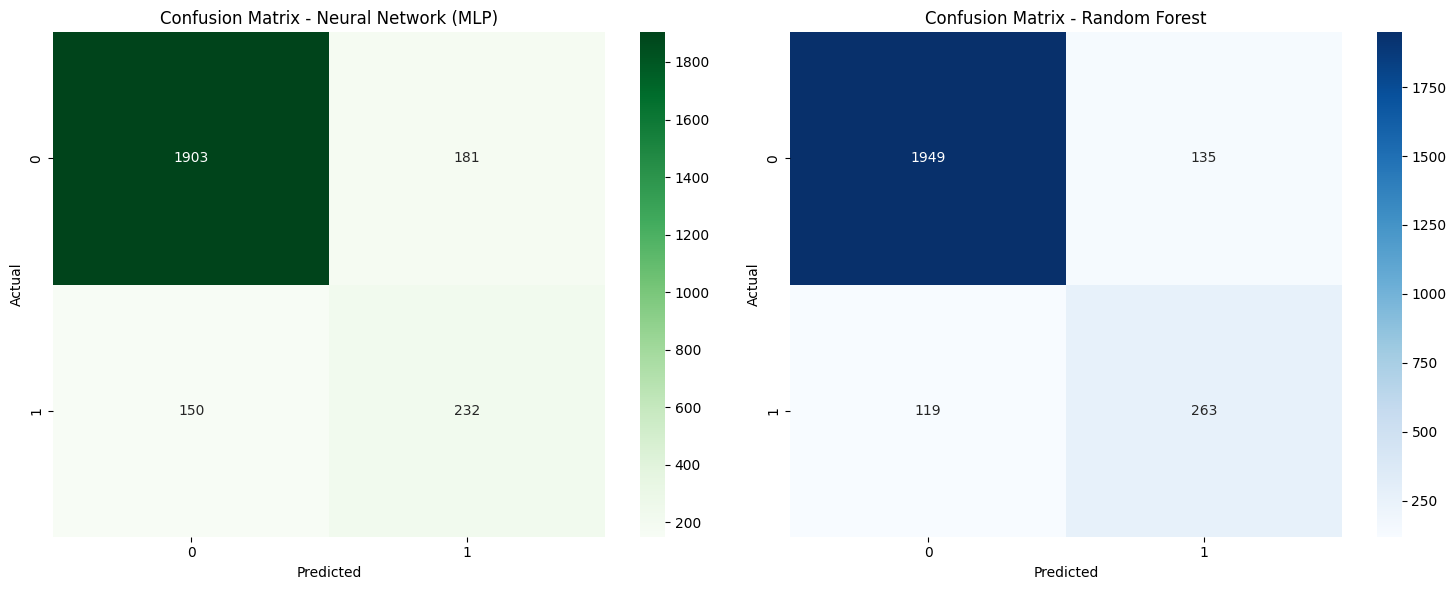

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat confusion matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix Neural Network
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Confusion Matrix - Neural Network (MLP)')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Confusion Matrix Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Confusion Matrix - Random Forest')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()